### Without using sigmoid function first 

In [60]:
from sklearn.datasets import make_classification

x, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=1,
    n_classes=2 ,
    n_clusters_per_class=1,
    class_sep=30.0,    # makes data clearly separable
    random_state=41,
    hypercube=False
)

In [79]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

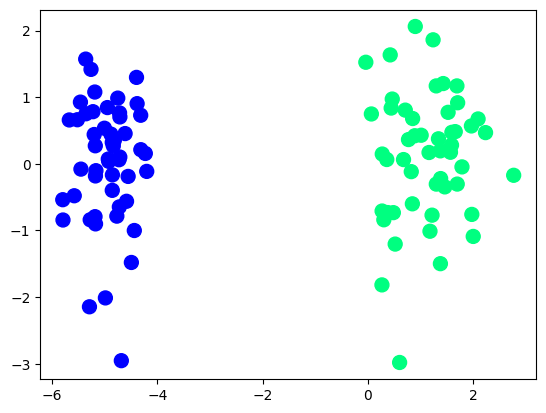

In [61]:
import matplotlib.pyplot as plt
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='winter',  s=100)

In [78]:
x.shape

(100, 2)

In [62]:
def step(z):
    return 1 if z >= 0 else 0

In [63]:
import numpy as np
def Perceptron(x, y):
    x = np.insert(x, 0, 1, axis=1)
    weights = np.ones(x.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0, 100)
        y_hat = step(np.dot(x[j], weights))
        weights = weights + lr * (y[j] - y_hat)*x[j]

    return weights[0], weights[1:]

In [64]:
intercept_, coef_ = Perceptron(x, y)

In [65]:
print(intercept_)

1.3000000000000003


In [66]:
print(coef_)

[1.1134548  0.33857969]


In [67]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [68]:
x_input = np.linspace(-3, 3, 100)
y_input = m*x_input + b

(-3.0, 2.0)

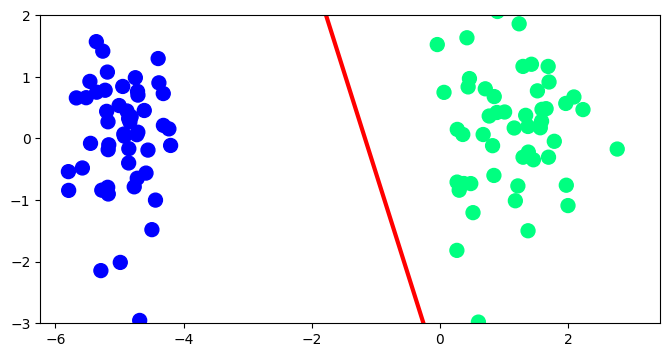

In [69]:
plt.figure(figsize=(8, 4))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)

#### We can see that the line is not lies on best place .

### Now using sigmoid 

In [70]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [71]:
def Perceptron(x, y):
    x = np.insert(x, 0, 1, axis=1)
    weights = np.ones(x.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0, 100)
        y_hat = sigmoid(np.dot(x[j], weights))
        weights = weights + lr * (y[j] - y_hat)*x[j]

    return weights[0], weights[1:]

In [72]:
intercept_, coef_ = Perceptron(x, y)

In [73]:
print(intercept_)

2.60469654687662


In [74]:
print(coef_)

[2.27771621 0.21231414]


In [75]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [76]:
x_input = np.linspace(-3, 3, 100)
y_input = m*x_input + b

(-3.0, 2.0)

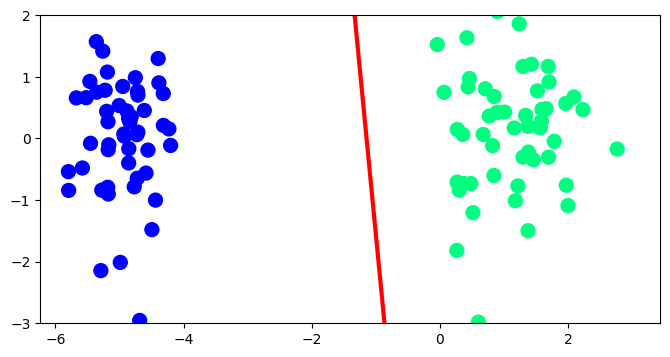

In [77]:
plt.figure(figsize=(8, 4))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)

#### We can see the difference in the line . It changes its position . Also not drawn as expected.